In [1]:
import os

def find_project_root(target_folder="hest1k-dataset"):
    path = os.getcwd()

    while True:
        if target_folder in os.listdir(path):
            return path

        parent = os.path.dirname(path)
        if parent == path:
            raise Exception("Project root not found")

        path = parent


# ---- ROOT ----
BASE_DIR = find_project_root()

# ---- DATA PATHS ----
DATA_DIR = os.path.join(BASE_DIR, "hest1k-dataset", "hest_multicancer")

WSI_DIR = os.path.join(DATA_DIR, "wsis")
ST_DIR = os.path.join(DATA_DIR, "st")
META_DIR = os.path.join(DATA_DIR, "metadata")

# ---- PROCESSED ----
PROCESSED_DIR = os.path.join(BASE_DIR,"data300", "processed")

os.makedirs(PROCESSED_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("META EXISTS:", os.path.exists(META_DIR))

BASE_DIR: c:\Users\dhanu\Documents\preliminary-gsoc\histMOE
DATA_DIR: c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\hest1k-dataset\hest_multicancer
PROCESSED_DIR: c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\data300\processed
META EXISTS: True


In [2]:
import os
import json
import numpy as np
import torch
import scanpy as sc
from PIL import Image
from tqdm import tqdm

In [3]:
import scanpy as sc

adatas = []
sample_ids = []

for meta_file in os.listdir(META_DIR):
    sample_id = meta_file.replace(".json", "")
    st_path = os.path.join(ST_DIR, f"{sample_id}.h5ad")

    if not os.path.exists(st_path):
        continue

    adata = sc.read_h5ad(st_path)
    adata.var_names_make_unique()

    adata.obs["sample_id"] = sample_id

    adatas.append(adata)
    sample_ids.append(sample_id)

print(f"Loaded {len(adatas)} samples")

c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded 6 samples


In [4]:
adata_all = sc.concat(adatas, join="outer", label="sample_id",fill_value=0)

c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
import numpy as np

np.random.seed(42)
# take subset of spots to reduce memory
n_cells = 5000   # you can try 3000–8000

idx = np.random.choice(adata_all.n_obs, n_cells, replace=False)
adata_sub = adata_all[idx].copy()

sc.pp.filter_genes(adata_sub, min_cells=10)
sc.pp.normalize_total(adata_sub, target_sum=1e4)
sc.pp.log1p(adata_sub)
sc.pp.scale(adata)

sc.pp.highly_variable_genes(
    adata_sub,
    n_top_genes=300,
    flavor="seurat"  
)

hvg_genes = adata_sub.var[adata_sub.var["highly_variable"]].index
print("HVG count:", len(hvg_genes))

c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


HVG count: 300


In [7]:
import numpy as np
from scipy.sparse import issparse

X = adata_all[:, hvg_genes].X  # already reduced to 300 HVGs

if issparse(X):
    mean = X.mean(axis=0).A1
    mean_sq = X.power(2).mean(axis=0).A1
else:
    mean = X.mean(axis=0)
    mean_sq = (X**2).mean(axis=0)

gene_std = np.sqrt(mean_sq - mean**2)

top_idx = np.argsort(gene_std)[-150:]
top_genes = np.array(hvg_genes)[top_idx]

print("Final gene count:", len(top_genes))

Final gene count: 150


In [8]:
def load_h5ad(file_path, selected_genes):
    import scanpy as sc
    import numpy as np
    from scipy.sparse import issparse

    adata = sc.read_h5ad(file_path)
    adata.var_names_make_unique()

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # ---- convert to dense safely ----
    if issparse(adata.X):
        X = adata.X.toarray()
    else:
        X = adata.X

    # ---- create fixed gene matrix ----
    gene_matrix = np.zeros((adata.n_obs, len(selected_genes)), dtype=np.float32)

    gene_to_idx = {g: i for i, g in enumerate(selected_genes)}

    for i, g in enumerate(adata.var_names):
        if g in gene_to_idx:
            gene_matrix[:, gene_to_idx[g]] = X[:, i]

    return gene_matrix, adata

COORDINATE SCALING

In [9]:
def get_scaled_coords(adata, json_path, wsi):

    coords = adata.obsm["spatial"].copy()

    # ---- SHIFT to remove negative offsets ----
    x_min, y_min = coords.min(axis=0)

    coords[:, 0] -= x_min
    coords[:, 1] -= y_min

    return coords

wsi loader

In [10]:
import os

os.add_dll_directory(
    r"C:\Users\dhanu\Downloads\openslide-bin-4.0.0.12-windows-x64\openslide-bin-4.0.0.12-windows-x64\bin"
)

import openslide

In [11]:

print(openslide.__version__)

1.4.3


In [12]:
def load_wsi(sample_id):
    path = os.path.join(WSI_DIR, f"{sample_id}.tif")
    slide = openslide.OpenSlide(path)
    return slide

patch extraction

In [13]:
def extract_patch(wsi, x, y, patch_size=128):
    x, y = int(x), int(y)
    half = patch_size // 2

    patch = wsi.read_region(
        (x - half, y - half),  # location
        0,                     # level (0 = highest resolution)
        (patch_size, patch_size)
    )

    patch = patch.convert("RGB")
    patch = np.array(patch)

    return patch

In [14]:
import json
import numpy as np

# ---- LABEL MAP ----
LABEL_MAP = {
    "COAD": 0,
    "LUAD": 1
}

def encode_metadata(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    # ---- label ----
    cancer = data["oncotree_code"]
    label = LABEL_MAP[cancer]

    # ---- categorical encodings ----
    organ_map = {"Bowel": 0, "Lung": 1}
    tissue_map = {"Colon": 0, "Lung": 1}
    preservation_map = {"FFPE": 0}

    organ = organ_map.get(data["organ"], 0)
    tissue = tissue_map.get(data["tissue"], 0)
    preservation = preservation_map.get(data["preservation_method"], 0)

    # one-hot
    organ_vec = np.zeros(len(organ_map))
    organ_vec[organ] = 1

    tissue_vec = np.zeros(len(tissue_map))
    tissue_vec[tissue] = 1

    preservation_vec = np.zeros(len(preservation_map))
    preservation_vec[preservation] = 1

    # ---- numeric features ----
    pixel_est = data["pixel_size_um_estimated"]
    pixel_emb = data["pixel_size_um_embedded"]

    numeric_vec = np.array([pixel_est, pixel_emb], dtype=np.float32)

    # ---- final metadata ----
    meta_vec = np.concatenate([
        organ_vec,
        tissue_vec,
        preservation_vec,
        numeric_vec
    ])

    return meta_vec.astype(np.float32), label

In [15]:
def get_coords(adata):

    x = adata.obs["pxl_col_in_fullres"].values
    y = adata.obs["pxl_row_in_fullres"].values

    coords = np.stack([x, y], axis=1)

    return coords

building index

In [16]:
index = []

for meta_file in os.listdir(META_DIR):

    sample_id = meta_file.replace(".json", "")

    json_path = os.path.join(META_DIR, meta_file)
    st_path = os.path.join(ST_DIR, f"{sample_id}.h5ad")

    if not os.path.exists(st_path):
        continue

    # ---- Metadata ----
    metadata_vec, label = encode_metadata(json_path)

    # ---- Load data ----
    gene_matrix, adata = load_h5ad(st_path, top_genes)
    genes = gene_matrix
    wsi = load_wsi(sample_id)
    coords = get_coords(adata)

    # FILTER HERE
    tissue_mask = adata.obs["in_tissue"] == 1

    coords = coords[tissue_mask]
    genes  = genes[tissue_mask]

    # ---- Loop ----
    for i in range(len(coords)):

        x, y = coords[i]
        gene = genes[i]

        patch = extract_patch(wsi, x, y)
        # percentage of white pixels
        white_ratio = (patch > 240).mean()

        if white_ratio > 0.5:
            continue

        if patch.std() < 10:
            continue

        if patch.shape != (128,128,3):
            continue


        index.append({
            "patch": patch,
            "gene": gene,
            "metadata": metadata_vec,
            "label": label,
            "sample_id": sample_id
        })

print("Total samples:", len(index))

c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\dhanu\Documents\preliminary-gsoc\histMOE\venv\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Total samples: 19413


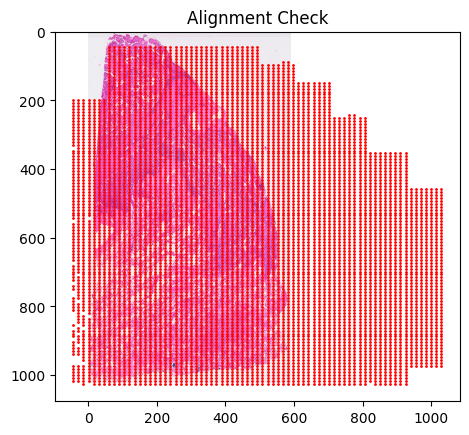

In [17]:
import matplotlib.pyplot as plt

slide = load_wsi(sample_id)

thumb = slide.get_thumbnail((1024, 1024))

plt.imshow(thumb)

# scale coords to thumbnail
w, h = slide.dimensions

coords_small = coords.copy()
coords_small[:, 0] *= (1024 / w)
coords_small[:, 1] *= (1024 / h)

plt.scatter(coords_small[:,0], coords_small[:,1], s=1, c='red')

plt.title("Alignment Check")
plt.show()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

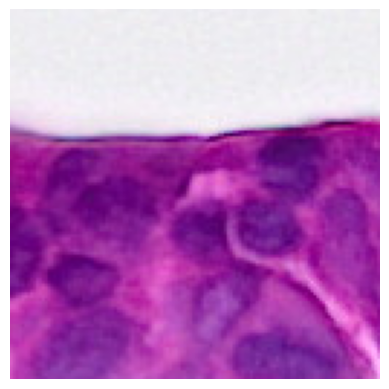

In [18]:
sample = index[100]

plt.imshow(sample["patch"])
plt.axis("off")

In [19]:
coords = adata.obsm["spatial"]

print("Coords min:", coords.min(axis=0))
print("Coords max:", coords.max(axis=0))

Coords min: [-1067.82458874  1903.91320478]
Coords max: [25206.02623391 43504.17700731]


In [20]:
slide = load_wsi(sample_id)

print("WSI size:", slide.dimensions)

WSI size: (25078, 43448)


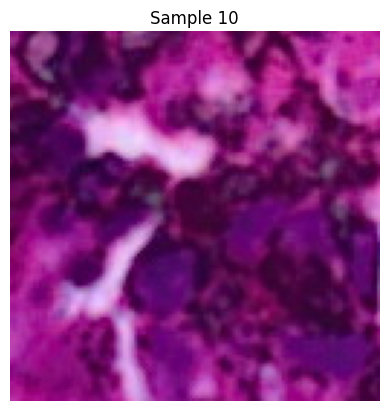

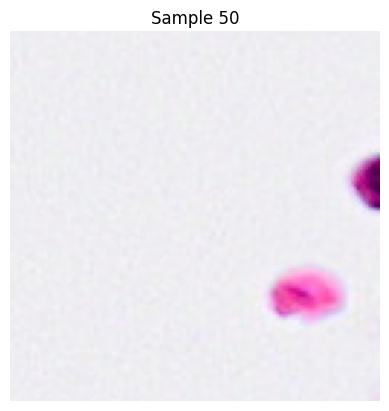

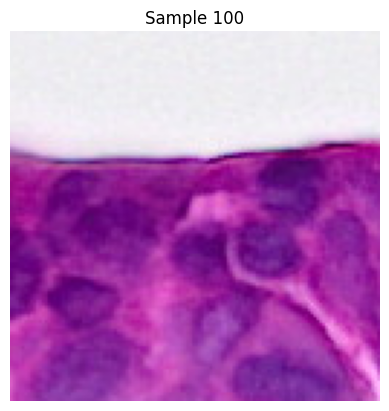

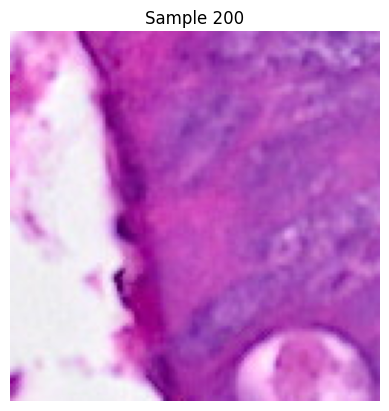

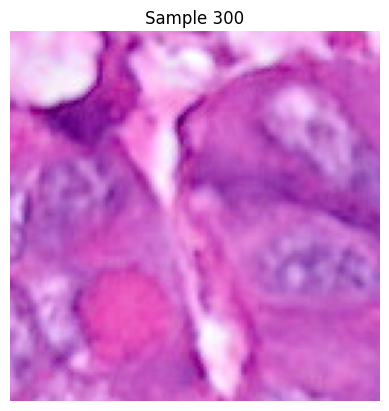

In [21]:
for i in [10, 50, 100, 200, 300]:
    plt.imshow(index[i]["patch"])
    plt.title(f"Sample {i}")
    plt.axis("off")
    plt.show()

In [22]:
print(adata.obs.columns)

Index(['in_tissue', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'array_col',
       'array_row', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes'],
      dtype='object')


In [23]:
import numpy as np

patches = np.array([x["patch"] for x in index])
genes   = np.array([x["gene"] for x in index])
meta    = np.array([x["metadata"] for x in index])
labels  = np.array([x["label"] for x in index])
sample_ids = np.array([x["sample_id"] for x in index])

print(patches.shape, genes.shape)

(19413, 128, 128, 3) (19413, 150)


In [24]:
os.makedirs("data/processed", exist_ok=True)
np.save(os.path.join(PROCESSED_DIR, "patches.npy"), patches)
np.save(os.path.join(PROCESSED_DIR, "genes.npy"), genes)
np.save(os.path.join(PROCESSED_DIR, "metadata.npy"), meta)
np.save(os.path.join(PROCESSED_DIR, "labels.npy"), labels)
np.save(os.path.join(PROCESSED_DIR, "sample_ids.npy"), sample_ids)